# EXPLORATORY DATA ANALYSIS (EDA)

In [2]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load cleaned data

data = pd.read_csv('cleaned_data.csv')

In [7]:
# Basic statistics

data.describe()

,order_id,customer_id,product_id,quantity,price,revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,503.930000,150.715500,25.568000,2.987500,64.827000,192.426500
std,288.625577,84.737493,14.290748,1.407599,31.191482,134.800865
min,1.000000,1.000000,1.000000,1.000000,10.000000,10.000000
25%,251.750000,81.000000,14.000000,2.000000,38.000000,84.000000
50%,507.000000,151.000000,25.000000,3.000000,66.500000,160.000000
75%,754.000000,223.000000,38.000000,4.000000,91.000000,280.000000
max,1000.000000,300.000000,50.000000,5.000000,119.000000,595.000000


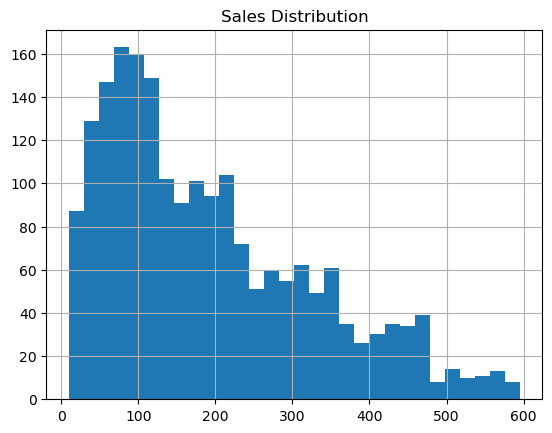

In [8]:
# Check Distribution

data['revenue'].hist(bins=30)
plt.title('Sales Distribution')
plt.show()

#### INSIGHTS:-
##### *Graph shows the "Positively Skewed" distribution.
##### *It indicates that most customers place small, low-cost orders and few rare customers place exceptionally large orders.

In [10]:
# Monthly Revenue

monthly_revenue = data.groupby('month')['revenue'].sum().sort_values(ascending=False)
monthly_revenue

month
October      39395.0
January      36716.0
August       36373.0
December     33697.0
April        32271.0
November     31095.0
March        31053.0
February     30085.0
May          30047.0
June         29313.0
July         28434.0
September    26374.0
Name: revenue, dtype: float64

### INSIGHTS:-
#### *Majority of months (7 out of 12) cluster predictably within a tight 28,000 to 32,000 bracket.
#### *Revenue experiences a sharp drop immediately following major peaks, collapsing from an August peak to a September floor before rebounding to an annual high in October.

In [13]:
# Top Products

top_products = data.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)
top_products

product_name
Product_16    10845.0
Product_23    10821.0
Product_25    10649.0
Product_47    10539.0
Product_45    10316.0
Product_13     9716.0
Product_6      9547.0
Product_42     9486.0
Product_4      9483.0
Product_14     9158.0
Name: revenue, dtype: float64

### INSIGHTS:-
#### *Core product performance is evenly balanced, no single product dominates the top-tier revenue mix.
#### *The top five products form a tight cluster, with each successfully crossing the 10,000 revenue threshold.
#### *The minimal 1,687.0 gap between the highest (Product_16) and lowest (Product_14) top ten assets indicates consistent consumer demand.

In [14]:
# Top Customers

top_cust = data.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head(10)
top_cust

customer_id
152    5388.0
13     5048.0
39     4564.0
231    3769.0
25     3509.0
144    3420.0
172    3416.0
76     3330.0
192    3275.0
268    3264.0
Name: revenue, dtype: float64

### INSIGHTS:-
#### * Customer_152 and Customer_13 act as significant positive outliers, both eclipsing the 5,000 spending mark.
#### *A steep 39% revenue decline exists between our number one customer and our number ten customer.

In [16]:
# Category Performance

top_cat = data.groupby('category')['revenue'].sum().sort_values(ascending=False)
top_cat

category
Hair      126301.0
Makeup    103662.0
Body       88177.0
Skin       66713.0
Name: revenue, dtype: float64

### INSIGHTS:-
#### *Hair and Makeup serve as the clear organizational anchors, driving 2,29,963.0 (nearly 60%) of overall company revenue.
#### * A steep 59,588.0 revenue delta separates the peak category (Hair) from the lowest-tier category (Skin).

In [14]:
# Country-wise Pivot Table

pivot_country = pd.pivot_table(
    data,
    values=['revenue','customer_id','order_id'],
    index='country',
    aggfunc={'revenue':'sum','customer_id':'nunique','order_id':'nunique'}
)
pivot_country =pivot_country.rename(columns={
    'revenue':'Total_Revenue','customer_id':'No Of Customers','order_id':'No Of Orders'
})
pivot_country = pivot_country.sort_values(
    by = 'Total_Revenue',ascending=False)
pivot_country

,No Of Customers,No Of Orders,Total_Revenue
country,,,
Italy,63,196,91076.0
Spain,57,193,83217.0
Morocco,57,167,79834.0
France,53,159,65995.0
Germany,47,146,64731.0


### INSIGHTS:-
#### *Italy generated the highest revenue (91,076) along with the highest number of customers and orders, indicating a strong and active customer base.
#### *Spain and Morocco show similar customer counts (57 each), but Spain generated higher revenue, suggesting better average order value or higher customer spending.
#### *Germany has the lowest customer count and orders among the top countries, resulting in comparatively lower revenue generation.
#### *Revenue generally increases with the number of orders and customers, indicating a positive relationship between customer activity and sales performance.

In [17]:
# Product-wise Pivot Table

pivot_product = pd.pivot_table(
    data,
    values=['revenue','customer_id','order_id'],
    index ='category',
    aggfunc={'revenue':'sum','customer_id':'nunique','order_id':'nunique'}
)
pivot_product = pivot_product.rename(columns={
    'revenue':'Total_Revenue','customer_id':'No Of Customers','order_id':'No Of Orders'
})

pivot_product = pivot_product.sort_values(
    by = 'Total_Revenue',
    ascending=False
)

pivot_product

,No Of Customers,No Of Orders,Total_Revenue
category,,,
Hair,239,505,126301.0
Makeup,213,417,103662.0
Body,202,351,88177.0
Skin,188,291,66713.0


In [22]:
# Correlation

correlation = data.corr(numeric_only=True)[['quantity','price','revenue']]
correlation

,quantity,price,revenue
order_id,0.001554,0.005961,0.003821
customer_id,0.009805,0.001515,-0.003290
product_id,0.012514,-0.031597,-0.015281
quantity,1.000000,-0.028352,0.645779
price,-0.028352,1.000000,0.672286
revenue,0.645779,0.672286,1.000000


### INSIGHTS:-
#### * The flat relationship (-0.03) between price and quantity proves that premium pricing tiers do not depress unit sales volume.

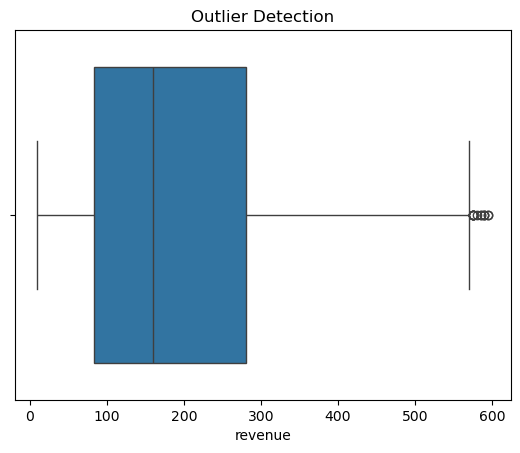

In [24]:
# Outlier Detection

sns.boxplot(x=data['revenue'])
plt.title("Outlier Detection")
plt.show()

### INSIGHTS:-
#### *The revenue distribution is positively skewed with a few high-value outliers, indicating that a small number of transactions contribute disproportionately to total sales.
#### *Most transactions fall within a moderate revenue range, showing customer purchasing behavior with only occasional premium or bulk purchases.

In [13]:
# Country-wise Pivot Table

pivot_country = pd.pivot_table(
    data,
    values=['revenue','customer_id','order_id'],
    index='country',
    aggfunc={'revenue':'sum','customer_id':'nunique','order_id':'nunique'}
)
pivot_country =pivot_country.rename(columns={
    'revenue':'Total_Revenue','customer_id':'No Of Customers','order_id':'No Of Orders'
})
pivot_country = pivot_country.sort_values(
    by = 'Total_Revenue',ascending=False)
pivot_country

,No Of Customers,No Of Orders,Total_Revenue
country,,,
Italy,63,196,91076.0
Spain,57,193,83217.0
Morocco,57,167,79834.0
France,53,159,65995.0
Germany,47,146,64731.0
